In [3]:
import pandas as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv("customer_segmentation_mixed.csv")
df.head()

,Age,Annual_Income,Spending_Score,Monthly_Visits,Gender,Preferred_Product
0,56,26102,85,6,Female,Clothing
1,46,70336,75,18,Male,Home
2,32,105314,36,10,Male,Groceries
3,60,46641,99,5,Female,Electronics
4,25,54584,19,10,Male,Electronics


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                350 non-null    int64 
 1   Annual_Income      350 non-null    int64 
 2   Spending_Score     350 non-null    int64 
 3   Monthly_Visits     350 non-null    int64 
 4   Gender             350 non-null    object
 5   Preferred_Product  350 non-null    object
dtypes: int64(4), object(2)
memory usage: 16.5+ KB


In [6]:
df.describe()

,Age,Annual_Income,Spending_Score,Monthly_Visits
count,350.000000,350.000000,350.000000,350.000000
mean,41.202857,71213.274286,49.571429,9.522857
std,13.422450,29311.239749,29.602801,5.584290
min,18.000000,20412.000000,1.000000,1.000000
25%,30.000000,45981.750000,24.000000,5.000000
50%,42.000000,71990.500000,51.000000,9.000000
75%,52.000000,97945.500000,75.000000,14.000000
max,64.000000,119835.000000,99.000000,19.000000


In [7]:
df.isnull().sum()

Age                  0
Annual_Income        0
Spending_Score       0
Monthly_Visits       0
Gender               0
Preferred_Product    0
dtype: int64

In [8]:
df.nunique()

Age                   47
Annual_Income        349
Spending_Score        98
Monthly_Visits        19
Gender                 2
Preferred_Product      5
dtype: int64

In [12]:
categorical_columns= df.select_dtypes(include=['object','category']).columns
for col in categorical_columns:
    print(f'value count of columns:{col}')
    print(df[col].value_counts())
    print('='*40)
    
    

value count of columns:Gender
Gender
Male      191
Female    159
Name: count, dtype: int64
value count of columns:Preferred_Product
Preferred_Product
Sports         83
Clothing       72
Home           67
Electronics    67
Groceries      61
Name: count, dtype: int64


In [13]:
counts=df.groupby(['Gender','Preferred_Product']).size().reset_index(name='Count')

print(counts)

   Gender Preferred_Product  Count
0  Female          Clothing     39
1  Female       Electronics     34
2  Female         Groceries     24
3  Female              Home     24
4  Female            Sports     38
5    Male          Clothing     33
6    Male       Electronics     33
7    Male         Groceries     37
8    Male              Home     43
9    Male            Sports     45


In [17]:
avg_spending=df.groupby('Gender')['Spending_Score'].mean().reset_index()
print(avg_spending)

   Gender  Spending_Score
0  Female       50.094340
1    Male       49.136126


In [18]:
df.head()

,Age,Annual_Income,Spending_Score,Monthly_Visits,Gender,Preferred_Product
0,56,26102,85,6,Female,Clothing
1,46,70336,75,18,Male,Home
2,32,105314,36,10,Male,Groceries
3,60,46641,99,5,Female,Electronics
4,25,54584,19,10,Male,Electronics


In [20]:
avg_visit=df.groupby('Gender')["Monthly_Visits"].mean().reset_index()

print(avg_visit)

   Gender  Monthly_Visits
0  Female        9.182390
1    Male        9.806283


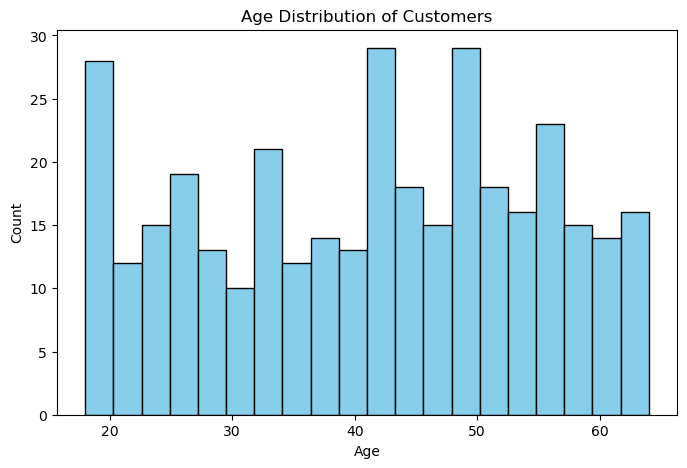

In [24]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Age'], 
    bins=20, 
    color='skyblue', 
    edgecolor='black'
)

plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

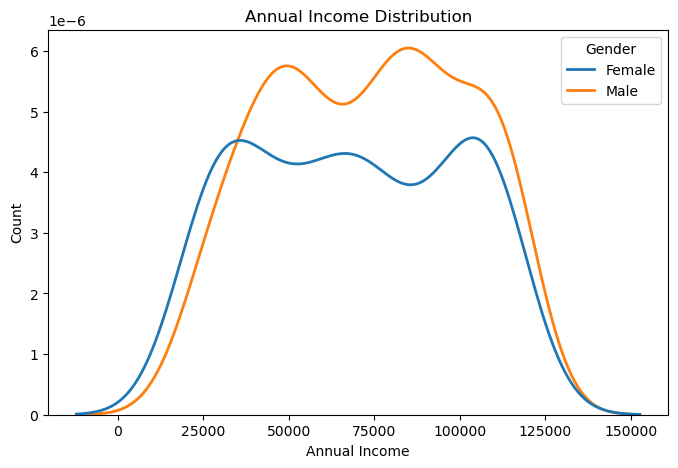

In [27]:
plt.figure(figsize=(8,5))

sns.kdeplot(data=df,x="Annual_Income",hue="Gender",
            fill=False,linewidth=2

)

plt.title('Annual Income Distribution')
plt.xlabel('Annual Income')
plt.ylabel('Count')

plt.show()

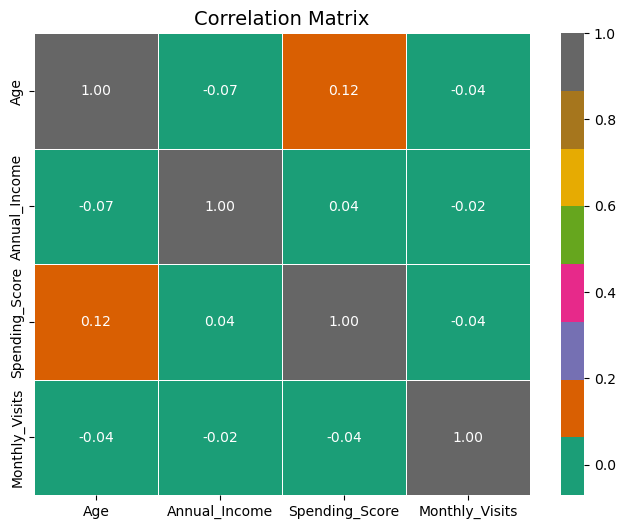

In [31]:
cols=["Age","Annual_Income", "Spending_Score", "Monthly_Visits"]
corr=df[cols].corr()
# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='Dark2', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix", fontsize=14)
plt.show()
